# Temperature Feature Engineering

The goal of this step is, given our historical data $T_1, T_2, \ldots, T_t$, to predict
the temperature $T_{t+1}$. We first focus on Chicago, then generalize to every city.

The methodology closely follows the paper
[Machine learning for temperature forecasting in weather derivatives](https://link.springer.com/article/10.1007/s10462-026-11539-0)
(Barnor, Kampouridis & Kanellopoulos, 2026).

In [1]:
import sys; sys.path.append("../../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import CLEANED_DIR, TRAIN_END, DATA_DIR
from data_cleaning import clean_data
from feature_engineering import (compute_doy_stats, build_features_v1,
                                 build_features_v2, feature_summary)

plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})
FOCUS = "chicago"
df_raw = pd.read_csv(f"{CLEANED_DIR}/{FOCUS}_ou_dataset.csv",
                     index_col=0, parse_dates=True)

We decomposed temperature into 2 components:
$$T_t = \underbrace{\theta_t}_{\text{deterministic}} + \underbrace{X_t}_{\text{stochastic}}$$

The deterministic component $\theta_t$ is estimated on the **training window only**, by OLS
regression on a Fourier series with a linear trend, as done in the previous notebooks. It captures the two phenomena identified earlier: seasonality, and the upward climatic trend driven by human activity and urbanisation.

### Choice of the target variable

**ML model target: $X_{t+1}$**, tomorrow's OU residual.

$X_t$ has a stationary distribution, so there is no need to re-learn the temperature seasonality.
Moreover, both model families (OU and ML) then predict the same mathematical object, so the
OU vs ML comparison is direct and not biased by a different choice of target.

Temperature is always reconstructed at the end of the pipeline, to recover the HDDs:
$$\hat{T}_{t+1} = \hat{X}_{t+1} + \theta_{t+1}$$
where $\theta_{t+1}$ is deterministic and known for any future date. No information is lost.

### Data cleaning & preprocessing

To clean the data before building features:

1. **Remove February 29.** This keeps 365 days per year and an identical structure across years,
   so no calendar day is under-represented.

2. **Impute missing $T$ values.** For each missing value at $t$:

$$T_{miss,t} = \frac{1}{2}\left(\underbrace{\frac{1}{N}\sum_{yr} T_{t,yr}}_{T_{Avy} : \text{same day, past years}} + \underbrace{\frac{\sum_{i=1}^{7}T_{t-i} + \sum_{i=1}^{7}T_{t+i}}{14}}_{T_{Avd} : \pm 7\text{-day window}}\right)$$

This method accounts for both the recent temperature dynamics and the seasonality
(Alexandridis & Zapranis, 2013b). The seasonal part is then removed to recover the missing
$X_t$.

The imputation itself is performed upstream by the OU pipeline. Here `data_cleaning.py` only runs
a light validation pass.

In [2]:
# Light validation (heavy lifting done upstream by ou_pipeline):
# sorting, Feb 29, X_t = T - theta check, structural epsilon NaNs
df_clean = clean_data(df_raw)


───────────────────────────────────────────────────────
  DATA CLEANING
───────────────────────────────────────────────────────
  ✓ Tri par date
  ✓ 29 février : aucun présent
  ✓ T : aucun NaN
  ✓ sigma_X_t : 1 NaN imputés (forward/backward fill)
  ✓ epsilon_t : 20 ligne(s) avec NaN supprimée(s) (première ligne, X_{t-1} indisponible)
  ✓ Vérification X_t = T - theta : OK (erreur max = 1.42e-14)

  Résultat : 27721 lignes
  Plage    : 1950-01-02 → 2026-01-01
  NaN sur colonnes clés : aucun ✓
───────────────────────────────────────────────────────


### Features

We build features based on temperature seasonality and trends :
- variables derived from the temperature history, ~50 features.

In [3]:
# Day-of-year climatology, TRAIN ONLY (no leakage)
df_train = df_clean[df_clean.index <= TRAIN_END]
doy_stats = compute_doy_stats(df_train, temp_col="T")

# Barnor-style historical features (Table 2), built on X_t
features_v1 = build_features_v1(df_clean, doy_stats)

# Inventory by block: the structure of the ~50 features
blocks = {
    "day index (d_t, d_t+1)":            [c for c in features_v1 if c.startswith("d_t")],
    "recent lags X_{t-1..7}":            [c for c in features_v1 if c.startswith("X_lag")],
    "previous years (A/B/C/D)":          [c for c in features_v1 if c.startswith(("X_1yr", "X_t1_")) or (c.startswith("X_") and c.endswith("yr"))],
    "doy climatology (mean, var)":       [c for c in features_v1 if c.startswith("doy_")],
    "differences ΔX and stats":          [c for c in features_v1 if c.startswith("dX")],
    "deterministic component θ":         [c for c in features_v1 if c == "theta"],
}
pd.DataFrame([{"block": k, "n features": len(v), "examples": ", ".join(v[:4])}
              for k, v in blocks.items()]).set_index("block")

  V1 (Barnor) : 27720 lignes × 50 features | lignes avec NaN : 2183


,n features,examples
block,,
"day index (d_t, d_t+1)",2,"d_t, d_t1"
recent lags X_{t-1..7},7,"X_lag1d, X_lag2d, X_lag3d, X_lag4d"
previous years (A/B/C/D),23,"X_1yr, X_2yr, X_3yr, X_4yr"
"doy climatology (mean, var)",2,"doy_mean, doy_var"
differences ΔX and stats,15,"dX_1d, dX_2d, dX_3d, dX_4d"
deterministic component θ,1,theta


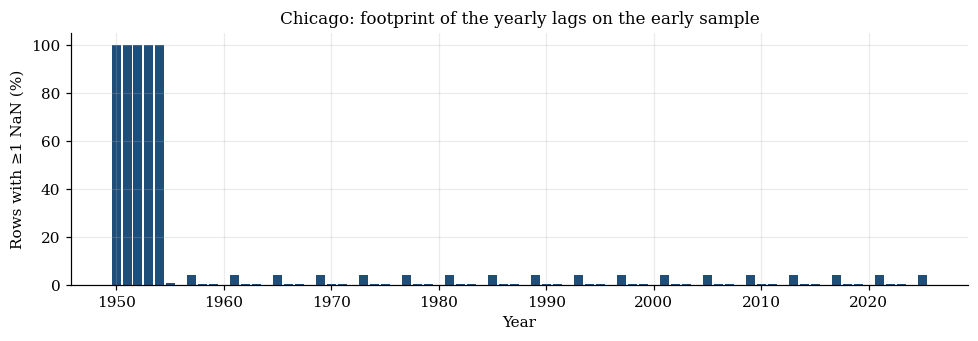

In [4]:
# NaN structure: yearly lags (up to -5 years) consume the first sample years,
# which is mechanical. The ML pipeline's SimpleImputer handles it, and it is one more
# reason to take the MEDIAN of hyperparameters across folds (fold 1 is
# degraded by construction).
nan_par_an = (features_v1.drop(columns=["target"]).isna().any(axis=1)
              .groupby(features_v1.index.year).mean() * 100)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(nan_par_an.index, nan_par_an.values, color="#1f4e79", width=0.85)
ax.set_xlabel("Year"); ax.set_ylabel("Rows with ≥1 NaN (%)")
ax.set_title(f"{FOCUS.title()}: footprint of the yearly lags on the early sample")
fig.tight_layout()

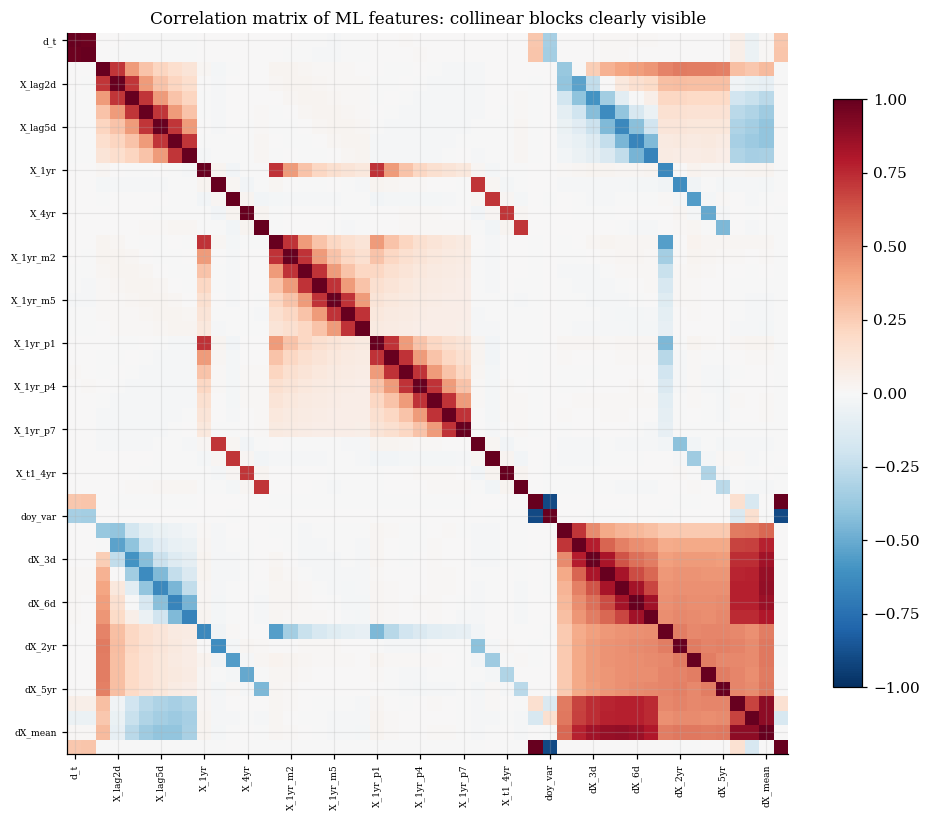

In [5]:
# Feature correlations (V1): the strong collinearity (lags <-> deltas, with
# deltas being EXACT linear combinations of the lags) explains why OLS diverges
# in recursive forecasting and why Ridge stabilizes it (shrinkage).
corr = features_v1.drop(columns=["target"]).corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ticks = np.arange(len(corr.columns))
ax.set_xticks(ticks[::3], corr.columns[::3], rotation=90, fontsize=6)
ax.set_yticks(ticks[::3], corr.columns[::3], fontsize=6)
ax.set_title("Correlation matrix of ML features: collinear blocks clearly visible")
fig.colorbar(im, shrink=0.8)
fig.tight_layout()

### V2 features: NWP reforecasts (GEFS)

We wanted to add to the V1 features other variables coming from reforcasts extracted from NOAA.

**Project status: abandoned.** The V2 block adds ~19 features from the GEFS J+1..J+7 reforecasts (2000 to 2025): deseasonalized forecasts `Xf_j1..j7`, dispersion `sigma_f`, trend `f_trend`, surprises `df_jk`, `hdd_implied`. An honest V1 vs V2 comparison requires the same evaluation folds (common period 2000+). Demonstration on Chicago. As the reforecast begin on 2000, compared to 1950 for initial features, we decide to drop this stage.

In [6]:
from nwp import load_nwp_all_years, build_nwp_features

NWP_DIR = DATA_DIR / "NOAA_forecast"
if NWP_DIR.exists():
    df_nwp = load_nwp_all_years(str(NWP_DIR), cities=[FOCUS])
    nwp_feats = build_nwp_features(df_nwp=df_nwp,
                                   doy_stats_map={FOCUS: doy_stats}, city=FOCUS)
    features_v2 = build_features_v2(df_clean, doy_stats, nwp_feats)
    display(nwp_feats.tail(3).round(3))
else:
    print("data/NOAA_forecast missing, V2 section skipped.")

✓ NWP chargé : 9000 jours (2000-01-01 → 2025-05-14)
  Colonnes (7) : ['chicago_j1', 'chicago_j2', 'chicago_j3', 'chicago_j4', 'chicago_j5', 'chicago_j6'] ...


  V2 (Barnor + NWP) : 27720 lignes × 69 features | NWP disponible : 8988 jours | lignes avec NaN : 18868


,Xf_j1,Xf_j2,Xf_j3,Xf_j4,Xf_j5,Xf_j6,Xf_j7,sigma_f,f_mean,f_trend,df_j1_abs,df_j2_abs,df_j3_abs,df_j4_abs,df_j5_abs,df_j6_abs,df_j7_abs,df_j7_signed,hdd_implied
date,,,,,,,,,,,,,,,,,,,
2025-05-12,-0.344,-0.673,2.394,4.075,-0.423,-7.579,-7.530,4.201,13.486,-5.27,0.57,0.12,2.53,2.02,3.57,6.52,5.71,-5.71,32.81
2025-05-13,-1.813,1.344,3.615,-0.443,-5.169,-8.040,-6.854,4.016,12.723,-3.97,0.60,2.18,1.55,4.82,3.98,0.37,0.70,0.70,37.69
2025-05-14,1.404,4.345,0.147,-5.509,-7.030,-5.634,-2.438,3.911,13.296,-2.64,3.38,3.33,3.77,4.30,1.77,2.43,4.71,4.71,34.41


---
These matrices feed `src/train_all.py` (nested CV 5×4, grids in `src/config.py`). The pricing-relevant evaluation (HDD/CAT APE by horizon) is in `5_ML_Evaluation&MC.ipynb`.
